In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
df_train=pd.read_csv('/kaggle/input/titanic/train.csv')

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_original_test=pd.read_csv('/kaggle/input/titanic/test.csv')

In [5]:
df_test=df_original_test.copy()

In [6]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df_gender=pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [8]:
df_gender.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [9]:
df_train.tail()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [10]:
df_train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [12]:
df_train.shape

(891, 12)

In [13]:
age_mean_train=df_train['Age'].mean()
df_train['Age'].fillna(age_mean_train,inplace=True)

/tmp/ipykernel_13/3341693693.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Age'].fillna(age_mean_train,inplace=True)


In [14]:
age_mean_test=df_test['Age'].mean()
df_test['Age'].fillna(age_mean_test,inplace=True)

/tmp/ipykernel_13/2638433755.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Age'].fillna(age_mean_test,inplace=True)


In [15]:
df_train['Cabin']=df_train['Cabin'].fillna("Unknown")

In [16]:
df_test['Cabin']=df_test['Cabin'].fillna("Unknown")

In [17]:
df_test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin          0
Embarked       0
dtype: int64

In [18]:
df_train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [19]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].mean())


In [20]:
df_test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [21]:
df_train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [22]:
df_train=df_train.dropna(subset=['Embarked'])


In [23]:
df_train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

<Axes: xlabel='Pclass', ylabel='Survived'>

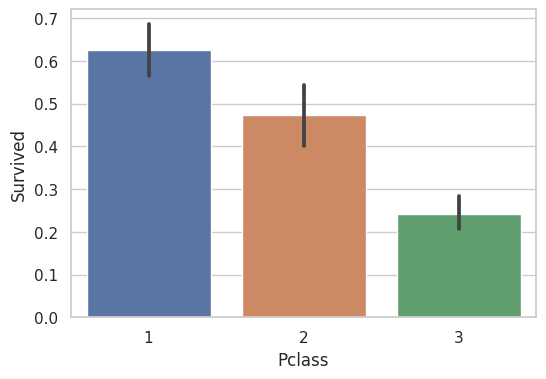

In [24]:
#relation between survived and Pclass
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass",y="Survived",data=df_train)

<Axes: xlabel='Sex', ylabel='Survived'>

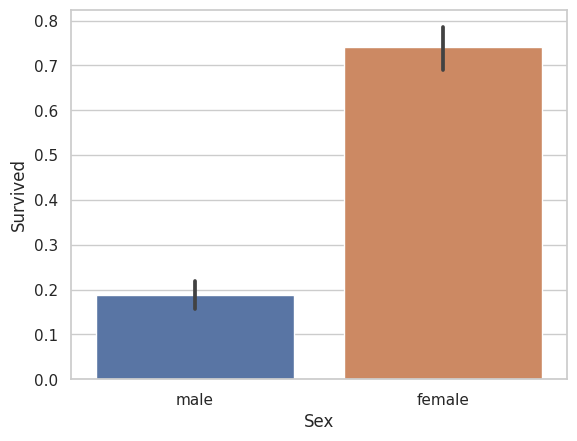

In [25]:
sns.barplot(x="Sex",y="Survived",data=df_train)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


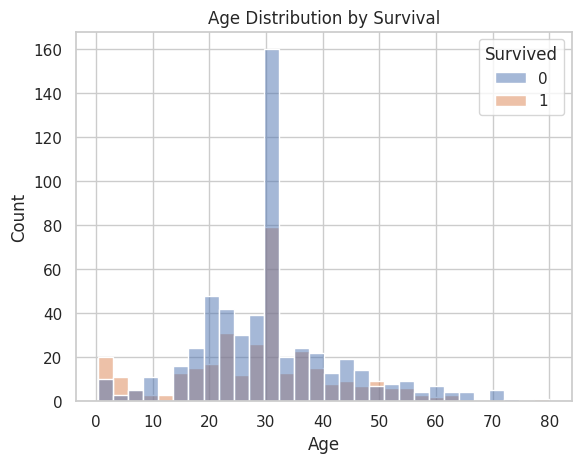

In [26]:
# sns.histplot(x="Age",y="Survived",data=df_train,bins=10)
sns.histplot(data=df_train, x='Age', hue='Survived', bins=30)
plt.title('Age Distribution by Survival')
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

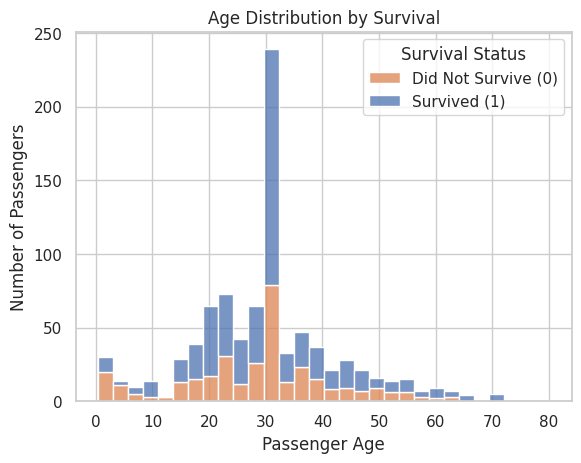

In [27]:
sns.histplot(data=df_train, x='Age', hue='Survived', bins=30, multiple="stack")
plt.title('Age Distribution by Survival')
plt.xlabel('Passenger Age')
plt.ylabel('Number of Passengers')
plt.legend(title='Survival Status', labels=['Did Not Survive (0)', 'Survived (1)'])
plt.show()


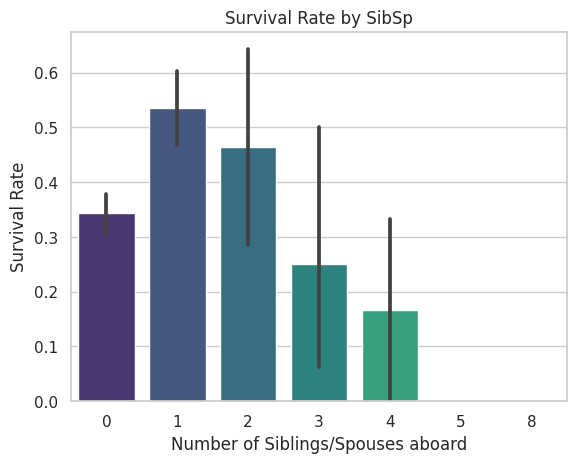

In [28]:
sns.barplot(x="SibSp", y="Survived", data=df_train, palette='viridis')
plt.xlabel("Number of Siblings/Spouses aboard")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by SibSp")
plt.show()


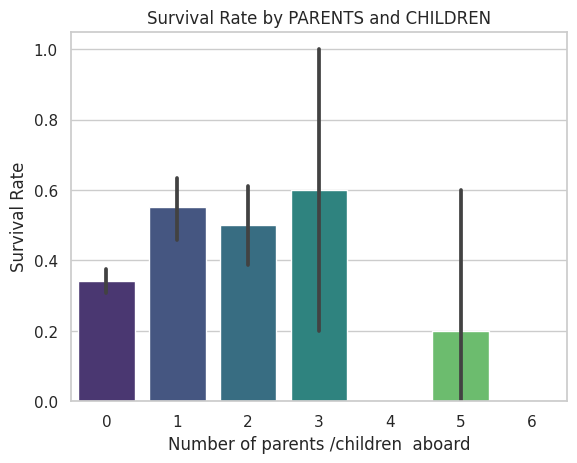

In [29]:
sns.barplot(x="Parch", y="Survived", data=df_train, palette='viridis')
plt.xlabel("Number of parents /children  aboard")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by PARENTS and CHILDREN")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='Fare', ylabel='Count'>

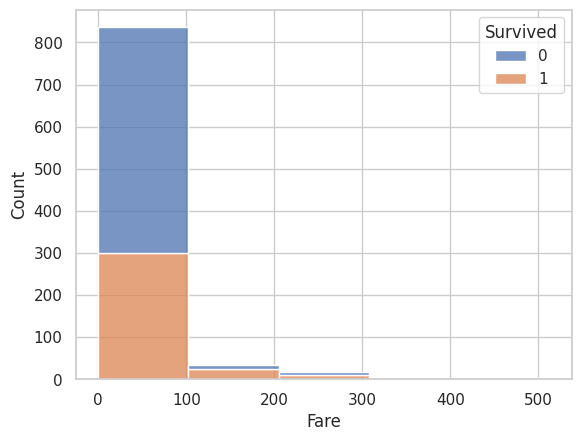

In [30]:
sns.histplot(x="Fare",data=df_train,hue='Survived', bins=5, multiple="stack")

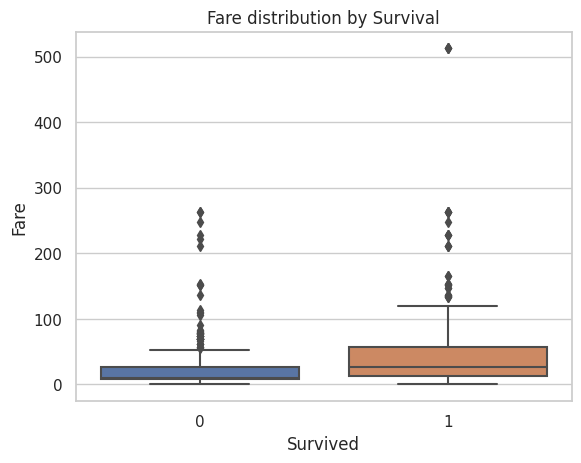

In [31]:
sns.boxplot(x="Survived", y="Fare", data=df_train)
plt.title("Fare distribution by Survival")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


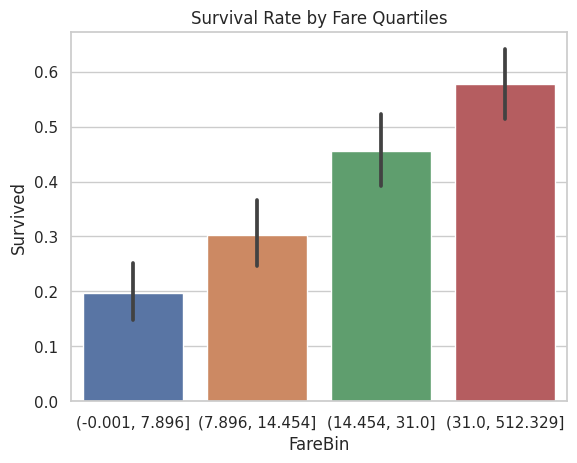

In [32]:
df_train['FareBin'] = pd.qcut(df_train['Fare'], 4)  # quartile bins
sns.barplot(x="FareBin", y="Survived", data=df_train)
plt.title("Survival Rate by Fare Quartiles")
plt.show()


In [33]:
df_test['Fare']

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [34]:

# Create Fare Bins by quartiles
df_train['FareBin'] = pd.qcut(df_train['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
df_test['FareBin'] = pd.qcut(df_test['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])


In [35]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Medium


In [36]:
df_test.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareBin
413,1305,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,Unknown,S,Medium
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C105,C,Very High
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,Unknown,S,Low
416,1308,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,Unknown,S,Medium
417,1309,3,"Peter, Master. Michael J",male,30.27259,1,1,2668,22.3583,Unknown,C,High


In [37]:

df_train['CabinDeck'] = df_train['Cabin'].map(lambda x: x[0] if x != 'Unknown' else 'U')


In [38]:
df_test['CabinDeck'] = df_test['Cabin'].map(lambda x: x[0] if x != 'Unknown' else 'U')


In [39]:
df_train.drop(['Fare','Name','Ticket','Cabin','PassengerId'],axis=1,inplace=True)
df_test.drop(['Fare','Name','Ticket','Cabin','PassengerId'],axis=1,inplace=True)

In [40]:
df_x_test=df_test

In [41]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,0,3,male,22.0,1,0,S,Low,U
1,1,1,female,38.0,1,0,C,Very High,C
2,1,3,female,26.0,0,0,S,Medium,U
3,1,1,female,35.0,1,0,S,Very High,C
4,0,3,male,35.0,0,0,S,Medium,U


In [42]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,3,male,34.5,0,0,Q,Low,U
1,3,female,47.0,1,0,S,Low,U
2,2,male,62.0,0,0,Q,Medium,U
3,3,male,27.0,0,0,S,Medium,U
4,3,female,22.0,1,1,S,Medium,U


In [43]:
df_train['Sex'].value_counts()

Sex
male      577
female    312
Name: count, dtype: int64

In [44]:
df_train['Sex']=df_train['Sex'].map({'male':0,'female':1})
df_test['Sex']=df_test['Sex'].map({'male':0,'female':1})

In [45]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,0,3,0,22.0,1,0,S,Low,U
1,1,1,1,38.0,1,0,C,Very High,C
2,1,3,1,26.0,0,0,S,Medium,U
3,1,1,1,35.0,1,0,S,Very High,C
4,0,3,0,35.0,0,0,S,Medium,U


In [46]:
df_x_test.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,3,0,34.5,0,0,Q,Low,U
1,3,1,47.0,1,0,S,Low,U
2,2,0,62.0,0,0,Q,Medium,U
3,3,0,27.0,0,0,S,Medium,U
4,3,1,22.0,1,1,S,Medium,U


In [47]:
df_x_train=df_train.drop(["Survived"],axis=1)
df_x_train


,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,3,0,22.000000,1,0,S,Low,U
1,1,1,38.000000,1,0,C,Very High,C
2,3,1,26.000000,0,0,S,Medium,U
3,1,1,35.000000,1,0,S,Very High,C
4,3,0,35.000000,0,0,S,Medium,U
...,...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,S,Medium,U
887,1,1,19.000000,0,0,S,High,B
888,3,1,29.699118,1,2,S,High,U
889,1,0,26.000000,0,0,C,High,C


In [48]:
df_y_train=df_train['Survived']
df_y_train

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64

In [49]:
# test data has no label out so 


In [50]:
categorical_features = ["Embarked", "FareBin", "CabinDeck"]
one_hot = OneHotEncoder(handle_unknown="ignore")  # important: ignore unknowns

# Create transformer
transformer = ColumnTransformer(
    [("one_hot", one_hot, categorical_features)],
    remainder="passthrough"
)

# Fit on train
transformed_x = transformer.fit_transform(df_x_train)

# Use the SAME transformer on test
transformed_test_x = transformer.transform(df_x_test)

# categorical_features=["Embarked","FareBin","CabinDeck"]
# one_hot=OneHotEncoder()

# transformer=ColumnTransformer([("one_hot",one_hot,categorical_features)],
#                               remainder="passthrough")
# transformer_test=ColumnTransformer([("one_hot",one_hot,categorical_features)],
#                               remainder="passthrough")

# transformed_x= transformer.fit_transform(df_train)
# transformed_test_x= transformer_test.fit_transform(df_test)

# transformed_x

In [51]:
df_x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Pclass     889 non-null    int64   
 1   Sex        889 non-null    int64   
 2   Age        889 non-null    float64 
 3   SibSp      889 non-null    int64   
 4   Parch      889 non-null    int64   
 5   Embarked   889 non-null    object  
 6   FareBin    889 non-null    category
 7   CabinDeck  889 non-null    object  
dtypes: category(1), float64(1), int64(4), object(2)
memory usage: 56.6+ KB


In [52]:
# Get one-hot encoded column names
one_hot_columns = transformer.named_transformers_['one_hot'].get_feature_names_out(categorical_features)


In [53]:
transformed_x


array([[ 0.        ,  0.        ,  1.        , ..., 22.        ,
         1.        ,  0.        ],
       [ 1.        ,  0.        ,  0.        , ..., 38.        ,
         1.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        , ..., 26.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., 29.69911765,
         1.        ,  2.        ],
       [ 1.        ,  0.        ,  0.        , ..., 26.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        , ..., 32.        ,
         0.        ,  0.        ]])

In [54]:
transformed_test_x

array([[ 0.        ,  1.        ,  0.        , ..., 34.5       ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        , ..., 47.        ,
         1.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        , ..., 62.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., 38.5       ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        , ..., 30.27259036,
         0.        ,  0.        ],
       [ 1.        ,  0.        ,  0.        , ..., 30.27259036,
         1.        ,  1.        ]])

In [55]:
# All column names
all_columns = list(one_hot_columns) + [col for col in df_x_train.columns if col not in categorical_features]
all_columns_test = list(one_hot_columns) + [col for col in df_x_test.columns if col not in categorical_features]

# Convert to DataFrame
transformed_xtrain_df = pd.DataFrame(transformed_x, columns=all_columns)
transformed_xtest_df = pd.DataFrame(transformed_test_x, columns=all_columns_test)



In [56]:
transformed_xtrain_df.head()


,Embarked_C,Embarked_Q,Embarked_S,FareBin_High,FareBin_Low,FareBin_Medium,FareBin_Very High,CabinDeck_A,CabinDeck_B,CabinDeck_C,...,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U,Pclass,Sex,Age,SibSp,Parch
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,22.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,38.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,26.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,35.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,35.0,0.0,0.0


In [57]:
transformed_xtest_df.head()


,Embarked_C,Embarked_Q,Embarked_S,FareBin_High,FareBin_Low,FareBin_Medium,FareBin_Very High,CabinDeck_A,CabinDeck_B,CabinDeck_C,...,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U,Pclass,Sex,Age,SibSp,Parch
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,34.5,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,47.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,62.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,27.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,22.0,1.0,1.0


In [58]:
# x=transformed_df.drop(['Survived'],axis=1)
df_y_train

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64

In [59]:
df_x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,3,0,22.0,1,0,S,Low,U
1,1,1,38.0,1,0,C,Very High,C
2,3,1,26.0,0,0,S,Medium,U
3,1,1,35.0,1,0,S,Very High,C
4,3,0,35.0,0,0,S,Medium,U


In [60]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(transformed_xtrain_df,df_y_train,test_size=0.2,random_state=42)


In [61]:
x_train.shape

(711, 21)

In [62]:
y_train.shape

(711,)

In [63]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=150,max_depth=20,random_state=42)

model.fit(x_train,y_train)

RandomForestClassifier(max_depth=20, n_estimators=150, random_state=42)

In [64]:
model.score(x_train,y_train)

0.9648382559774965

In [65]:
model.score(x_test,y_test)

0.7808988764044944

In [66]:
x_test

,Embarked_C,Embarked_Q,Embarked_S,FareBin_High,FareBin_Low,FareBin_Medium,FareBin_Very High,CabinDeck_A,CabinDeck_B,CabinDeck_C,...,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U,Pclass,Sex,Age,SibSp,Parch
280,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,28.0,0.0,0.0
434,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,14.0,1.0,2.0
39,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,14.0,1.0,0.0
417,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,30.0,0.0,0.0
584,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,18.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,17.0,0.0,0.0
806,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,18.0,0.0,0.0
25,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,38.0,1.0,5.0
84,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,33.0,3.0,0.0


In [67]:
y_preds=model.predict(x_test)

In [68]:
model.score(x_test,y_test)

0.7808988764044944

In [69]:
df_test

,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,3,0,34.50000,0,0,Q,Low,U
1,3,1,47.00000,1,0,S,Low,U
2,2,0,62.00000,0,0,Q,Medium,U
3,3,0,27.00000,0,0,S,Medium,U
4,3,1,22.00000,1,1,S,Medium,U
...,...,...,...,...,...,...,...,...
413,3,0,30.27259,0,0,S,Medium,U
414,1,1,39.00000,0,0,C,Very High,C
415,3,0,38.50000,0,0,S,Low,U
416,3,0,30.27259,0,0,S,Medium,U


In [70]:
transformed_xtest_df.head()

,Embarked_C,Embarked_Q,Embarked_S,FareBin_High,FareBin_Low,FareBin_Medium,FareBin_Very High,CabinDeck_A,CabinDeck_B,CabinDeck_C,...,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U,Pclass,Sex,Age,SibSp,Parch
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,34.5,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,47.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,62.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,27.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,22.0,1.0,1.0


In [71]:
transformed_xtest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Embarked_C         418 non-null    float64
 1   Embarked_Q         418 non-null    float64
 2   Embarked_S         418 non-null    float64
 3   FareBin_High       418 non-null    float64
 4   FareBin_Low        418 non-null    float64
 5   FareBin_Medium     418 non-null    float64
 6   FareBin_Very High  418 non-null    float64
 7   CabinDeck_A        418 non-null    float64
 8   CabinDeck_B        418 non-null    float64
 9   CabinDeck_C        418 non-null    float64
 10  CabinDeck_D        418 non-null    float64
 11  CabinDeck_E        418 non-null    float64
 12  CabinDeck_F        418 non-null    float64
 13  CabinDeck_G        418 non-null    float64
 14  CabinDeck_T        418 non-null    float64
 15  CabinDeck_U        418 non-null    float64
 16  Pclass             418 non

In [72]:
test_preds=model.predict(transformed_xtest_df)

In [73]:
test_preds

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [74]:
transformed_xtest_df.head()

,Embarked_C,Embarked_Q,Embarked_S,FareBin_High,FareBin_Low,FareBin_Medium,FareBin_Very High,CabinDeck_A,CabinDeck_B,CabinDeck_C,...,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U,Pclass,Sex,Age,SibSp,Parch
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,34.5,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,47.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,62.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,27.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,22.0,1.0,1.0


In [75]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,FareBin,CabinDeck
0,3,0,34.5,0,0,Q,Low,U
1,3,1,47.0,1,0,S,Low,U
2,2,0,62.0,0,0,Q,Medium,U
3,3,0,27.0,0,0,S,Medium,U
4,3,1,22.0,1,1,S,Medium,U


In [76]:
df_original_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [77]:
submission = pd.DataFrame({
    "PassengerId": df_original_test["PassengerId"],  # must come from original test.csv
    "Survived": test_preds   # 1D array is fine
})

# Save for Kaggle
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv ready with shape:", submission.shape)
submission.head()

✅ submission.csv ready with shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
